In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
! pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [4]:
#  Load data
df = pd.read_csv('/content/stroke.csv')
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.5,0.816895,0.0,1.0,1.0,0.50,1.0,0.801265,0.301260,0.333333,1
1,0.0,0.743652,0.0,0.0,1.0,0.75,0.0,0.679023,0.212981,0.666667,1
2,0.5,0.975586,0.0,1.0,1.0,0.50,0.0,0.234512,0.254296,0.666667,1
3,0.0,0.597168,0.0,0.0,1.0,0.50,1.0,0.536008,0.276060,1.000000,1
4,0.0,0.963379,1.0,0.0,1.0,0.75,0.0,0.549349,0.156930,0.666667,1


In [5]:
#  Preprocessing
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

In [6]:
#  Features & target
X = df.drop('stroke', axis=1)
y = df['stroke']


In [7]:
#  Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [8]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Build
model=Sequential([
    Dense(32,activation='relu',input_shape=(X_train.shape[1],)),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [10]:
#Compile
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
# train
history=model.fit(X_train,y_train,
                  epochs=20,
                  batch_size=32,
                  validation_split=0.2)


Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7616 - loss: 0.5208 - val_accuracy: 0.8001 - val_loss: 0.4483
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8031 - loss: 0.4369 - val_accuracy: 0.8066 - val_loss: 0.4280
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8121 - loss: 0.4209 - val_accuracy: 0.8123 - val_loss: 0.4197
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8169 - loss: 0.4094 - val_accuracy: 0.8130 - val_loss: 0.4089
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8179 - loss: 0.3996 - val_accuracy: 0.8201 - val_loss: 0.4051
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8214 - loss: 0.3913 - val_accuracy: 0.8136 - val_loss: 0.4004
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8232 - loss: 0.3835 - val_accuracy: 0.8136 - val_loss: 0.3933
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8254 - loss: 0.3775 - val_accuracy: 0.

In [12]:
# predict
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [13]:
# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Stoke Model-> loss:",loss)
print("Stoke Model-> accuracy:",accuracy)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8463 - loss: 0.3528
Stoke Model-> loss: 0.3528219759464264
Stoke Model-> accuracy: 0.8462724685668945


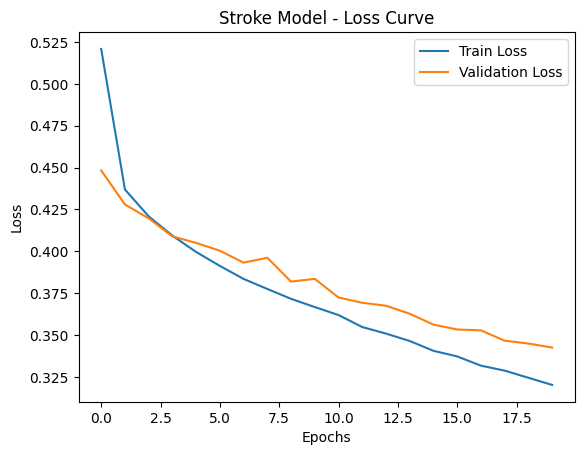

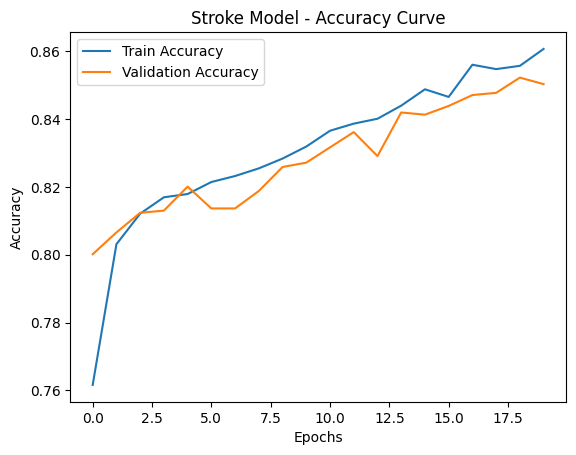

In [14]:

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Stroke Model - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Stroke Model - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[729 246]
 [ 53 917]]
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       975
           1       0.79      0.95      0.86       970

    accuracy                           0.85      1945
   macro avg       0.86      0.85      0.84      1945
weighted avg       0.86      0.85      0.84      1945



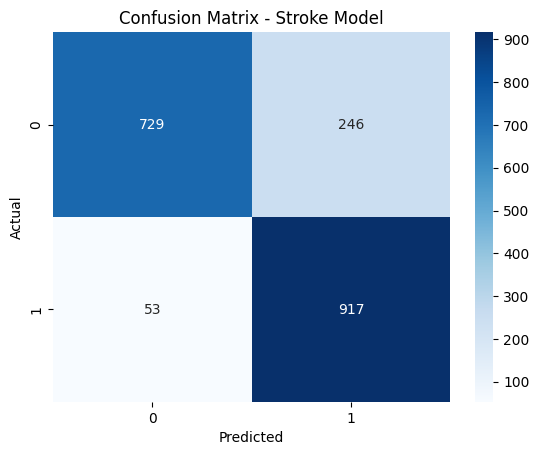

In [16]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Stroke Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

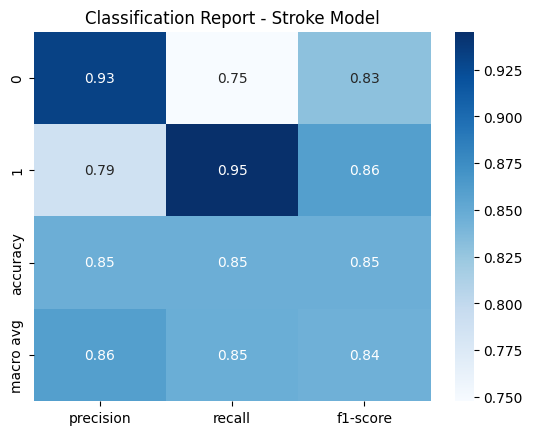

In [17]:


report = classification_report(y_test, predictions, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure()
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues')

plt.title('Classification Report - Stroke Model')
plt.show()